# Data Science I
<div style="position: relative;">
    <div style="position: absolute; top: -60px; right: 10px; padding: 5px; background-color: transparent; font-size: 20px; text-align: right;">
        <span>Version: October 10, 2025</span>
    </div>
</div>

## Project Report: Predicting Energy Prices
<span style="font-weight: bold; text-decoration: underline;">Submission Deadline: January 25 2026, 21:00 UTC</span>
    
**University of Oldenburg**<br/>
**Winter 2025/2026**<br/>
**Instructors**: [Jannik Schröder](https://uol.de/team-data/jannik-schroeder), [Wolfram "Wolle" Wingerath](https://uol.de/wolle)

<span style="font-weight: bold; ">Submitted by: <span style="color: red;">Kryvtsova Vlada, Winkler David, Brüning Menko</span>

---

# Introduction
Electricity markets require generators, traders, and large consumers to plan production and consumption ahead of time. In Europe, one of the most important reference markets is the **day-ahead market**, where participants submit bids and offers for each delivery hour of the next day. The market is then cleared so that supply meets demand, resulting in a separate hourly price (€/MWh) for each hour of the following day. These prices can vary strongly due to demand patterns, renewable generation, fuel costs, and seasonal effects, and they may even become negative during periods of high renewable supply and low demand.

The goal of this project is to forecast Germany’s day-ahead electricity prices for a specific target date, **January 27, 2026**, using historical data from 2023–2026. We frame the task as an **hourly supervised forecasting problem** with the target variable being the price for delivery hour *t*. As explanatory variables, we use a compact set of drivers available in our dataset. Some of them are the previous day’s price, forecasts for load, wind and solar generation, calendar variables.

To assess the value of increasing model complexity, we implement and compare four levels of models: 
*  **Level 0**: naive persistence baseline (“tomorrow equals yesterday”)
*  **Level 1**: seasonal time-series model (SARIMA)
*  **Level 2**: linear regression model using multiple features
*  **Level 3**: machine-learning model (XGBoost).

Models are evaluated with time-aware splits and standard error metrics to ensure a fair comparison without information leakage. The report presents the dataset, modeling choices, evaluation methodology, and results, and concludes with limitations and potential improvements for future work.

<a id="data-preprocessing"></a>
# Part 1. Gathering Data Sources

## 1.1 Time span
The dataset used in this project combines several time series that are relevant for forecasting German day-ahead electricity prices. The data covers the period **from January 1, 2023 to January 25, 2026** with an hourly resolution. This time span is chosen to focus on a period of relatively stable market conditions.

As shown in the figure below, electricity prices in 2022 experienced extreme spikes. These spikes were caused by a geopolitical shock following Russia’s reduction of natural gas supplies to Europe. While these events are historically important, they represent exceptional market conditions that are not well explained by the variables used in this project.

By starting the analysis in 2023, the models are trained on data that better reflects typical price dynamics in the German day-ahead electricity market. This leads to lower model prediction errors. The selected time span is still sufficiently long to allow robust training and evaluation, while avoiding distortions caused by rare crisis events.

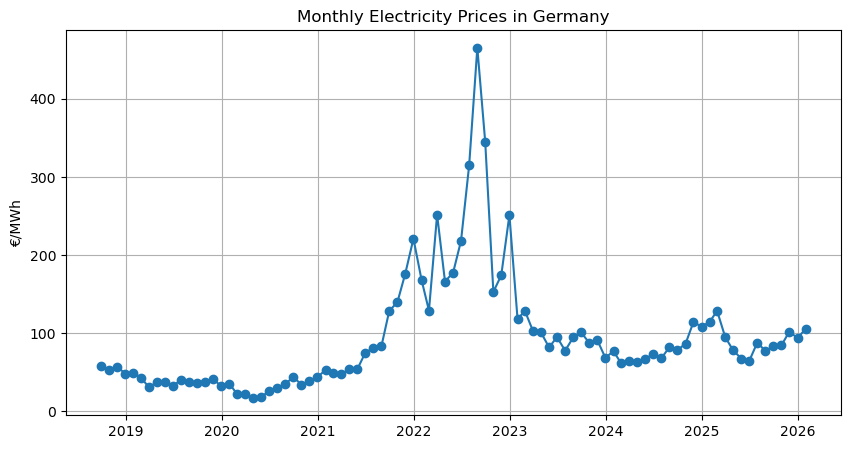

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd

electricity_prices = pd.read_csv("entsoe_forecasts.csv")
electricity_prices["Date"] = pd.to_datetime(
    electricity_prices["Date"],
    utc=True
)

electricity_prices = electricity_prices.set_index("Date").sort_index()

monthly_prices = electricity_prices["Price_DayAhead"].resample("ME").mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_prices, marker='o')
plt.title("Monthly Electricity Prices in Germany")
plt.ylabel("€/MWh")
plt.grid(True)
plt.show()

## 1.2 Data Parameters & Sources

### 1.2.1 ENTSO-E Transparency Platform

The primary data source for electricity market variables is the ENTSO-E Transparency Platform ([transparency.entsoe.eu](https://transparency.entsoe.eu)), the official publication platform of the European Network of Transmission System Operators for Electricity. Data was accessed via the `entsoe-py` Python library.

The day-ahead prices originate from the Single Day-Ahead Coupling (SDAC), a pan-European mechanism that couples national wholesale electricity markets. The market clearing occurs daily around 12:00 CET, determining prices for each delivery hour of the following day.

| Column | Description | Unit | Source | Role |
|--------|-------------|------|--------|------|
| Date | Timestamp in hourly resolution (UTC) | - | - | Index |
| Price_DayAhead | Day-ahead electricity market clearing price | €/MWh | `query_day_ahead_prices` | Target (y) |
| Load_Forecast | Day-ahead forecasted total electricity demand | MW | `query_load_forecast` | Feature (X) |
| Solar | Day-ahead forecasted solar generation | MW | `query_wind_and_solar_forecast` | Feature (X) |
| Wind_Offshore | Day-ahead forecasted offshore wind generation | MW | `query_wind_and_solar_forecast` | Feature (X) |
| Wind_Onshore | Day-ahead forecasted onshore wind generation | MW | `query_wind_and_solar_forecast` | Feature (X) |

### 1.2.2 Open-Meteo Weather API

To capture weather-driven effects on electricity demand and renewable generation, we sourced hourly weather forecast data from the Open-Meteo API ([open-meteo.com](https://open-meteo.com)), an open-source weather API. We used the Historical Forecast API (`historical-forecast-api.open-meteo.com`) for past data and the Forecast API (`api.open-meteo.com`) for current predictions. Weather data was aggregated from six major German cities: Hamburg, Berlin, Leipzig, Frankfurt, Cologne, and Munich.

| Column | Description | Unit | API Parameter | Role |
|--------|-------------|------|---------------|------|
| timestamp | Hourly timestamp (Europe/Berlin → UTC) | - | - | Index |
| Weather_Temp_Forecast | Mean air temperature at 2m across six cities | °C | `temperature_2m` | Feature (X) |
| Weather_Wind_Forecast | Mean wind speed at 100m across six cities | m/s | `windspeed_100m` | Feature (X) |
| Weather_Solar_Forecast | Mean global horizontal irradiance across six cities | W/m² | `shortwave_radiation` | Feature (X) |

## 1.3 Data Cleaning 

In [2]:
# setting starting point as January 1st, 2023
electricity_prices = electricity_prices[electricity_prices.index > "2023-01-01"]

### 1.3.1 Unification

Because Europe’s coupled day-ahead electricity market switched to 15-minute pricing for delivery starting 1 October 2025, ENTSO-E’s published day-ahead series follows that market design. To avoid mixed-frequency time series (hourly, then quarter-hourly), the first step is to unify them by converting everything to hourly.

In [3]:
# compute time differences between consecutive timestamps
time_diffs = electricity_prices.index.to_series().diff()

hourly_step = pd.Timedelta(hours=1)

# find first timestamp where the step is smaller than 1 hour
change_point = time_diffs[time_diffs < hourly_step].index.min()

df_hourly = electricity_prices.resample("h").mean()

To make working with data easier, we are combinig the electricity and weather data in one data set. The goal is to achieve an hour-aligned merge. However, the timestamps in weather data are time-naive, while those in electricity data are time-aware. So, we decided to join the data sets using UTC in both of them.

In [4]:
weather = pd.read_csv(
    "weather_forecasts_aggregated.csv",
    index_col=0,
    parse_dates=True
)

# convert weather data to UTC
df_weather_hourly = (
    weather
    .tz_localize("Europe/Berlin", nonexistent="shift_forward", ambiguous=False)
    .tz_convert("UTC")
)

# unify electricity & weather based on UTC
df = df_hourly.join(df_weather_hourly, how="inner")
df.head()

,Price_DayAhead,Load_Forecast,Solar,Wind_Offshore,Wind_Onshore,Weather_Temp_Forecast,Weather_Wind_Forecast,Weather_Solar_Forecast
2023-01-01 01:00:00+00:00,-1.47,39059.02,0.0,3403.22,35232.53,13.6,40.3,0.0
2023-01-01 02:00:00+00:00,-5.08,37631.41,0.0,3421.21,34975.61,13.1,40.0,0.0
2023-01-01 03:00:00+00:00,-4.49,37770.84,0.0,3420.97,34064.78,13.2,40.1,0.0
2023-01-01 04:00:00+00:00,-5.40,37342.54,0.0,3445.44,33617.55,12.6,40.1,0.0
2023-01-01 05:00:00+00:00,-5.02,35192.27,0.0,3462.39,33488.25,12.4,40.0,0.0


### 1.3.2 Cleaning
Next we will identify the missing values.

In [5]:
print(df.isna().sum())

Price_DayAhead            3
Load_Forecast             7
Solar                     8
Wind_Offshore             5
Wind_Onshore              8
Weather_Temp_Forecast     0
Weather_Wind_Forecast     0
Weather_Solar_Forecast    0
dtype: int64


We can see that the data for **forecasted demand** is one of the most mising values. One of the best ways to handle missing values in time series is **time-series interpolation**. It is a method to estimate missing values using nearby known values. It assumes the variable changes smoothly over time and estimates missing points from neighboring timestamps, making it suitable for short gaps in continuous, ordered data. That being said, we firstly need to examine *Load_Forecast* to see whether it follows a particular trend.

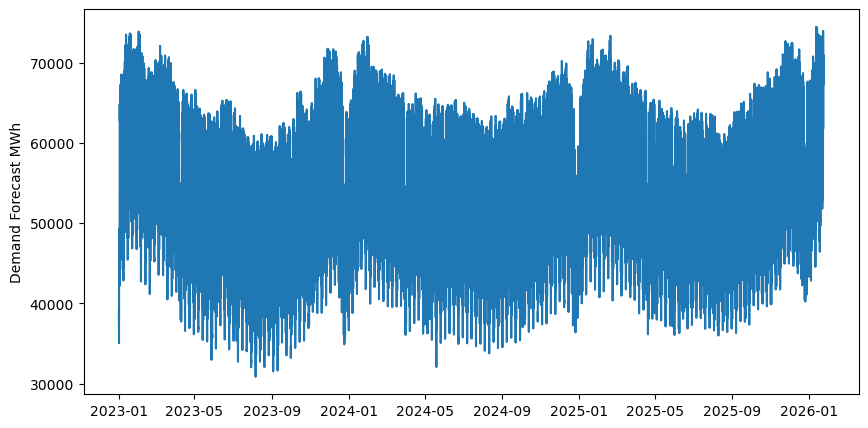

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Load_Forecast"])
plt.ylabel("Demand Forecast MWh")
plt.show()

**Conclusion:** There is a strong seasonal trend. Fluctuations are smooth and continious. Therefore, for this case time-based interpolation is a good choice to handle missing values.

In [7]:
# apply time-based interpolation
df["Load_Forecast"] = (
    df["Load_Forecast"]
    .interpolate(method="time")
)
missing_load_forecast = df["Load_Forecast"].isna().sum()
if missing_load_forecast == 0:
    print("Load forecast has no more missing values.")
else:
    print("Load forecast has missing values.")

Load forecast has no more missing values.


The same approach applies to **solar** and **wind** production forecasts, since both are continuous physical processes. That being said, short gaps are best filled by **time interpolation** to preserve realistic, smooth temporal evolution rather than freezing (e.g. forward-fill) or flattening (mean-fill) the signal.

> Note: Zero values are actual legitimate values that represent no production (e.g. no solar energy production during the night).

In [8]:
for col in ["Solar", "Wind_Onshore", "Wind_Offshore"]:
    df[col] = (
        df[col]
        .interpolate(method="time", limit=3)
        .clip(lower=0)
    )
    
solar_wind_missing = df['Solar'].isna().sum() + df['Wind_Offshore'].isna().sum() + df['Wind_Onshore'].isna().sum()

if solar_wind_missing == 0:
    print("Solar/wind forecast has no missing values.")
else:
    print("Solar/wind has missing values.")

Solar/wind forecast has no missing values.


There are also some missing **day ahead** prices. However, three missing prices in a multi-year hourly series are negligible. So, the best option, in our opinion, would be to just **drop** them.

In [9]:
df = df.dropna(subset=["Price_DayAhead"])

***Final cleaning check:***

In [10]:
print(df.isna().sum())

Price_DayAhead            0
Load_Forecast             0
Solar                     0
Wind_Offshore             0
Wind_Onshore              0
Weather_Temp_Forecast     0
Weather_Wind_Forecast     0
Weather_Solar_Forecast    0
dtype: int64


# Part 2. Exploratory Data Analysis

## 2.1 Statistical summaries

In [11]:
df.describe()

,Price_DayAhead,Load_Forecast,Solar,Wind_Offshore,Wind_Onshore,Weather_Temp_Forecast,Weather_Wind_Forecast,Weather_Solar_Forecast
count,26849.000000,26849.000000,26849.000000,26849.000000,26849.000000,26849.000000,26849.000000,26849.000000
mean,88.035152,53605.089739,7291.330499,2864.941265,12991.212536,11.571813,21.465738,124.257876
std,51.185842,9056.345568,11174.767627,1824.203948,10006.464377,7.642898,9.056716,189.489660
min,-500.000000,30848.600000,0.000000,12.300000,202.980000,-8.200000,2.500000,0.000000
25%,65.760000,46235.420000,0.000000,1187.200000,5061.790000,5.700000,15.000000,0.000000
50%,90.417500,53360.580000,162.600000,2753.760000,10254.470000,11.200000,20.000000,6.000000
75%,113.180000,60993.650000,11656.070000,4481.420000,18589.590000,17.300000,25.800000,192.400000
max,936.280000,74511.838791,51062.840000,7097.032500,46793.530000,36.200000,66.600000,880.900000


**Day-Ahead Prices** exhibit substantial variability but are not strongly skewed. The mean (≈ 88 €/MWh) and median (≈ 90 €/MWh) are very close, indicating a relatively balanced central tendency. The interquartile range spans roughly from 65 €/MWh (25th percentile) to 113 €/MWh (75th percentile), showing that half of the observed prices lie within a moderate range. At the same time, the full range extends from −500 €/MWh to over 900 €/MWh, revealing the presence of rare but extreme price events.\
\
Below the distribution of day-ahead prices is demonstarted visually. It is dominated by a main peak at typical price levels but also shows a distinct concentration near zero. Its long tails reflect rare extreme price events.

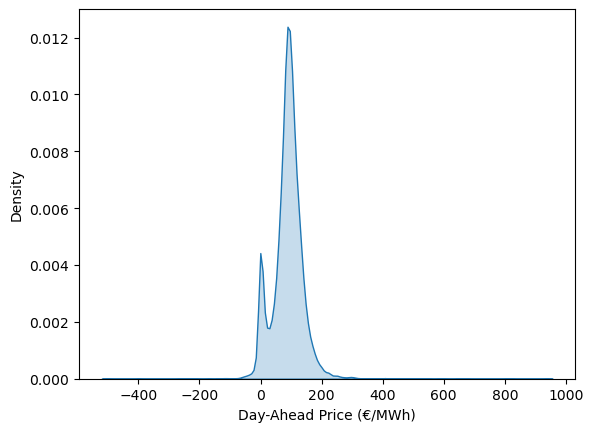

In [12]:
import seaborn as sns

sns.kdeplot(df["Price_DayAhead"], fill=True)
plt.xlabel("Day-Ahead Price (€/MWh)")
plt.show()

**Forecasted Demand** Forecasted demand is much more stable. The mean and median are nearly identical, and the interquartile range is narrow compared to the total range, indicating a smooth and approximately symmetric distribution. The absence of extreme outliers reflects the predictable nature of electricity demand. \
\
**Solar production** is strongly right-skewed and zero-inflated. The 25th percentile is zero, while the median is very small relative to the mean, showing that a large fraction of hours have little or no solar output (nighttime).
**Wind offshore** and **Wind onshore** both show broad spreads. The mean exceeds the median in both cases, implying right-skewness, but unlike solar, the minimum values are strictly positive.\
\
**Weather temperature forecast** is relatively symmetric, with mean and median close and a bounded range that aligns with realistic Central European temperatures. This suggests a well-behaved, near-normal distribution, which makes it easier for models to learn from. **Solar and wind weather forecasts** imply similar behaviour as solar and wind production forecasts, which is exactly what we would want to expect.

## 2.2 Investigation of Relationships 


### Demand <-> Price 
Firstly, we will look at how the forecasted demand correlates with actual day-ahead electricity prices. 

In [13]:
from scipy import stats
spearman_corr, _ = stats.spearmanr(df['Load_Forecast'], df['Price_DayAhead'])
pearson_corr = df['Load_Forecast'].corr(df['Price_DayAhead'])
print(f"Pearson rank corr: {pearson_corr}")
print(f"Spearman rank corr: {spearman_corr}")

Pearson rank corr: 0.2886072803303733
Spearman rank corr: 0.2802394397505874


**Interpretation:** higher expected demand tends to coincide with higher prices, but demand alone explains only a limited part of price variation (weak correlation). Electricity prices correlate more with residual load, since demand on isolation does not imply much information (e.g. high demand with high renewables would not result in higher prices; moderate demand with low renewables could still result in high prices). Additionally, fuel prices, imports, bidding behavior add noise.

### (Demand & Renewables) <-> Price
Now, we will look at how the forecasted demand correlates with forecasted energy production from renewables using the formula for residual load. Residual load is the part of electricity demand that remains after subtracting variable renewable generation. The formula for hour *t* is
$$\text{Residual Load}_{t} = \text{Load}_{t} - \text{Wind}_{t} - \text{Solar}_{t}$$
High residual load means that renewables cower little of demand. Therefore, more conventional plants are needed, which results in higher electricity prices. It works the opposite way for low residual load, since in this case renewables cower most/all demand. \
\
This implies that residual load should strongly correlate with electricity prices. So, this is what we'll be testing next using **Spearman's rank** correlation. This correlation type is better suited for electricity price analysis because it captures monotonic but nonlinear relationships and is robust to extreme price spikes (e.g. sharp price spikes during scarcity events).

In [14]:
from scipy import stats
residual_load = df['Load_Forecast'] - df['Solar'] - df['Wind_Offshore'] - df['Wind_Onshore']
corr, _ = stats.spearmanr(df['Price_DayAhead'], residual_load)
print(f"Correlation between electricity prices and residual load: {corr}")

Correlation between electricity prices and residual load: 0.8602484760455739


**Interpretation:** The residual load shows a strong positive correlation with day-ahead prices. This indicates that higher residual load leads to higher day-ahead electricity. Even though substantial variability still remains due to unexplained market, fuel, and network effects, correlation rate of 0.86 motivates adding Residual Load as a model parameter.

### Demand <-> Weather

Next we will look at how forecasted weather correlates with forecasted demand. In this case we would expect the correlation index to be very low. This is because the relationship between these two variales is non-linear. Intuitively it is expected that cold weather leads to higher electricity prices (heating demand), as well as hot weather (cooling demand), while mild weather results in lower prices. So, it is better to investigate this relationship separately for hot and cold weather.

In [15]:
print(f"Demand to weather correlation: {df['Load_Forecast'].corr(df['Weather_Temp_Forecast'])}")
cold_temp = df.query('Weather_Temp_Forecast <= 0')['Weather_Temp_Forecast']
print(f"Demand to COLD weather correlation: {df['Load_Forecast'].corr(cold_temp)}")
hot_temp = df.query('Weather_Temp_Forecast >= 27')['Weather_Temp_Forecast']
print(f"Demand to HOT weather correlation: {df['Load_Forecast'].corr(hot_temp)}")

Demand to weather correlation: -0.15018623941817116
Demand to COLD weather correlation: -0.021098529062301644
Demand to HOT weather correlation: -0.019976108314476947


**Interpretation:** Even after calculating the correlation between two weather conditions separately, actual average temperature seem to significantly affect neither the expected demand or, therefore, the price.

### Renewables <-> Weather

Since residual load has a moderate to strong correlation with day-ahead prices, it is good to investigate the fact whether forecasted weather significantly impacts forecasted renewable energy production.

In [16]:
print(f"Solar production to shortwave radiation corr: {df['Solar'].corr(df['Weather_Solar_Forecast'])}")

df["Wind_Mean"] = df[["Wind_Offshore", "Wind_Onshore"]].mean(axis=1)
corr = df["Wind_Mean"].corr(df["Weather_Wind_Forecast"])
print(f"Mean wind production to wind speed corr: {corr}")

Solar production to shortwave radiation corr: 0.9705990280271973
Mean wind production to wind speed corr: 0.8914680859483397


**Interpretation:** Since the correlation is very strong in both cases, weather features, which we gathered, are meaningful and not random noise.

### Day Type <-> Price
Because electricity demand and market behavior differ systematically between weekdays, weekends, and public holidays, it is also important to investigate the relationship between day types and electricity prices. Weekdays typically exhibit higher industrial and commercial demand, leading to higher prices, while weekends and holidays show reduced activity and lower demand, often resulting in lower prices. These calendar effects are highly regular and cannot be fully captured by lagged prices or weather variables alone.

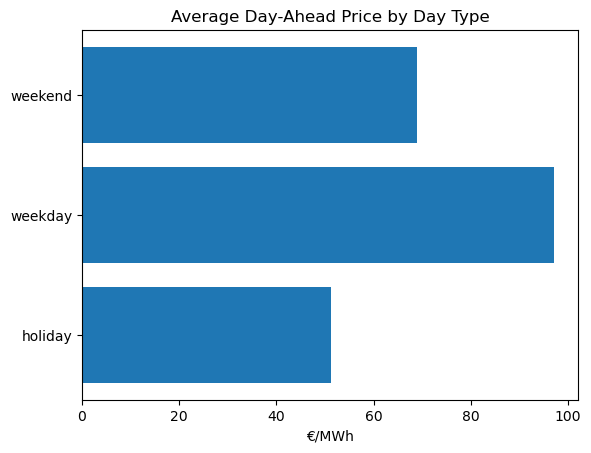

In [17]:
!pip install holidays
import matplotlib.pyplot as plt
import holidays

# extract holidays for Germany for time period in our data set
years = range(df.index.year.min(), df.index.year.max() + 1)
de_holidays = holidays.Germany(years=years)

# assign day types
df['is_holiday'] = pd.Series(df.index.date, index=df.index).isin(de_holidays)
df['is_weekend'] = df.index.weekday >= 5
df['is_weekday'] = ~df['is_weekend']
df['day_type'] = 'weekday'
df.loc[df['is_weekend'], 'day_type'] = 'weekend'
df.loc[df['is_holiday'], 'day_type'] = 'holiday'

day_type_prices_avg = df.groupby('day_type')['Price_DayAhead'].mean().reset_index()

plt.figure()
plt.barh(day_type_prices_avg['day_type'], day_type_prices_avg['Price_DayAhead'])
plt.xlabel('€/MWh')
plt.title('Average Day-Ahead Price by Day Type')
plt.show()

**Interpretation:** the above mentioned expectations are confirmed.
* Weekdays: higher industrial and commercial demand -> higher prices
* Weekends: reduced economic activity -> lower demand -> lower prices
* Public holidays: demand often drops even further than on weekends

This motivates adding day type as a model parameter.

### Day Time <-> Price
Next we will be investigating the relationship between day-ahead electricity prices and the hour of the day. This is essential, because intuitively market bidding behavior should strongly follow recurring intraday cycles. To do so, we are plotting the median of prices for every hour of they day. The median is chosen, because according to the statistical analysis done earlier, the day-ahead prices have some extreme outliers and median is more stable for cases like this one.

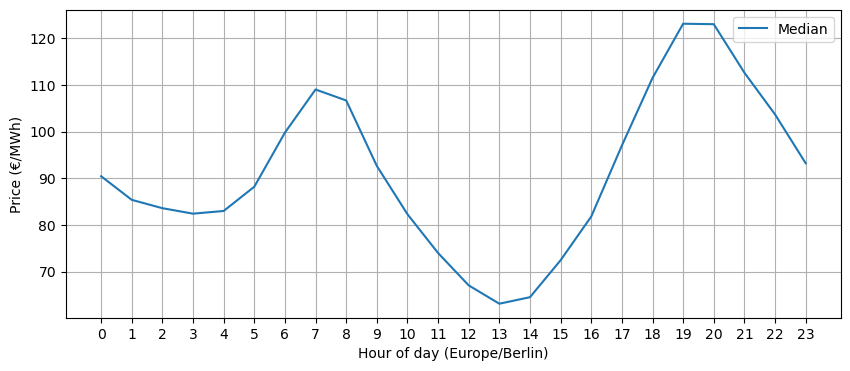

In [18]:
df_berlin = df.copy()
df_berlin['hour'] = df_berlin.index.tz_convert("Europe/Berlin").hour
hour_profile = df_berlin.groupby('hour')['Price_DayAhead'].agg(['median'])

plt.figure(figsize=(10, 4))
plt.plot(hour_profile.index, hour_profile["median"], label="Median")
plt.xticks(range(0, 24))
plt.xlabel("Hour of day (Europe/Berlin)")
plt.ylabel("Price (€/MWh)")
plt.grid(True)
plt.legend()
plt.show()

**Interpretation:** 

* Night hours (01–05): lower prices due to reduced demand
* Morning peak (07–08): rising prices as demand increases
* Midday dip (12–14): lower prices (probably partly driven by solar generation)
* Evening peak (18–21): highest prices, reflecting peak demand and limited supply flexibility

Such seasonality is a strong motivator to use day time is model parameter. Capturing those patterns could allow models to distinguish structural daily price effects from random market fluctuations. 

# Part 3. Modelling

## Level 0: Naive persistance (baseline)
As a reference point we use a naive persistence model as a baseline. The baseline assumes that the day-ahead electricity price for a given delivery hour is equal to the realized price of the same hour on the previous day. Formally, the forecast is defined as
$$\hat{P_t} = P_{t-24}$$
Model performance is evaluated using the **Mean Absolute Error (MAE)** and the **Root Mean Squared Error (RMSE)**. MAE describes the typical difference between predicted and observed prices. RMSE gives more weight to larger errors. Using both measures helps to assess average prediction accuracy and the effect of occasional larger deviations. We will be using the values calculated for the baseline model to evaluate the performence of the following models.

In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_base = df.copy()

# creating baseline prediction
df_base["y_true"] = df_base["Price_DayAhead"]
df_base["y_pred_lvl0"] = df_base["Price_DayAhead"].shift(24)

# dropping first 24 hours
df_base = df_base.dropna(subset=["y_true", "y_pred_lvl0"])

y_test = df_base["y_true"]
p_test = df_base["y_pred_lvl0"]

# computing metrics
mae_base = mean_absolute_error(y_test, p_test)
rmse_base = mean_squared_error(y_test, p_test) ** 0.5

print(f"MAE : {mae_base:.3f} €/MWh")
print(f"RMSE: {rmse_base:.3f} €/MWh")

MAE : 27.056 €/MWh
RMSE: 41.811 €/MWh


The figure below shows the observed versus predicted day-ahead electricity prices for the naive persistence baseline, where the forecast for each hour equals the observed price 24 hours earlier.

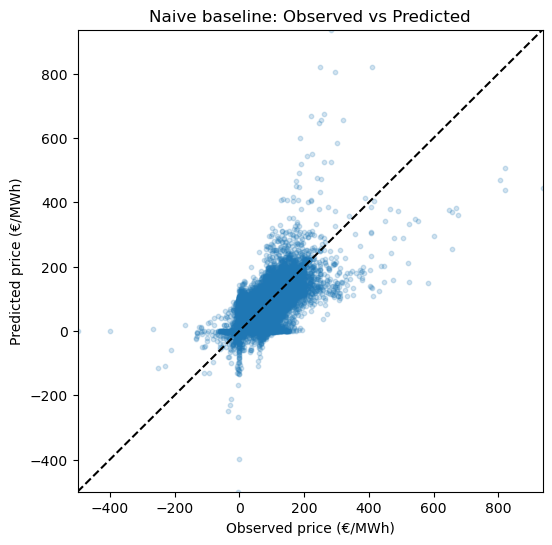

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, p_test, alpha=0.2, s=10)
lims = [
    min(y_test.min(), p_test.min()),
    max(y_test.max(), p_test.max())
]

plt.plot(lims, lims, linestyle="--", color="black")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Observed price (€/MWh)")
plt.ylabel("Predicted price (€/MWh)")
plt.title("Naive baseline: Observed vs Predicted")
plt.show()

**Plot summary:** Most observations lie close to the diagonal, indicating that the baseline captures short-term price persistence. However, at moderately high price levels around 200 €/MWh, predictions begin to deviate noticeably from the diagonal. This indicates that the naive baseline loses accuracy already outside typical price ranges and is unable to reliably anticipate larger price movements.

## Level 1: SARIMA
The Seasonal ARIMA (SARIMA) model is a univariate time-series forecasting method that extends the classical ARIMA framework by explicitly accounting for seasonal patterns. It models the current value of a time series as a function of its past values, past forecast errors, and recurring seasonal effects.

SARIMA relies solely on the historical values of the target variable and does not incorporate external explanatory information. As a result it cannot directly respond to changes in the fundamental drivers, which will be discuseed later in the project. SARIMA is therefore used as our intermediate model that remains less expressive than models with exogenous variables.

### Step 1: Preparing data and extracting target & parameters
A fixed hourly frequency is required by SARIMAX to correctly model temporal dependencies and seasonal patterns, especially the strong 24-hour cycle present in electricity prices. Thus this is done by explicitly setting the Pandas time frequency to hourly.  

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

pd.set_option('future.no_silent_downcasting', True)
df_sar = df.copy()
df_sar = df_sar[~df_sar.index.duplicated(keep="first")]
df_sar = df_sar.asfreq("h") 
df_sar = df_sar.ffill().bfill() 

df_sar = df_sar.dropna()

# target
y = df_sar['Price_DayAhead']

### Step 2: Dividing data into train, validate and test sets
The data are divided into training, validation, and test sets using a chronological split. Everything up to June 1st, 2025 is used for training, while 20% of it is reserved for validation for hyperparamater tuning. The rest of the data is used for testing.

In [22]:
split_time_test = "2025-06-01"
y_train_full = y.loc[y.index < split_time_test]
y_test = y.loc[y.index >= split_time_test]

# validation (last 20% of training)
val_frac = 0.2
cut = int(len(y_train_full) * (1 - val_frac))
y_train = y_train_full.iloc[:cut]
y_val   = y_train_full.iloc[cut:]
print(f"Training samples: {len(y_train)}")
print(f"Validation samples: {len(y_val)}")
print(f"Test samples: {len(y_test)}")

Training samples: 16933
Validation samples: 4234
Test samples: 5685


### Step 3: Hyperparameter tuning with cross-validation

A Seasonal ARIMA (SARIMA) model is specified as 
$$\text{SARIMA}(p,d,q)(P,D,Q,s)$$
where 
| Parameter | Description |
|-----------|-------------|
| `p` | How many past values the model looks at |
| `d` | How many times the series is differenced to remove trends |
| `q` | How many past errors are used |
| `P` | How many past seasonal values the model looks at |
| `D` | How many times seasonal patterns are removed |
| `Q` | How many past seasonal errors are used |
| `s` | Length of one season (e.g. 24 hours for daily seasonality) |

Code below is used to identify the best hyperparameter configuration, a grid search is performed over a restricted set of SARIMA orders with p,q$\in${0,1,2}, d$\in${0,1}, P,D,Q$\in${0,1}. The seasonal period is set to s=24 to reflect daily seasonality in hourly electricity prices. For each candidate configuration the model is estimated using the training data and its performance is evaluated on a separate validation set. The configuration that has the lowest validation error is selected as the final model. 
The code is commented out due to runtime considerations, while the resulting parameter choices are used in the final SARIMA specification.

In [23]:
import itertools

def fit_sarima(y_train, order, seasonal_order):
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit(disp=False)

def eval_forecast(res, y_val):
    fc = res.get_forecast(steps=len(y_val)).predicted_mean
    mae = mean_absolute_error(y_val, fc)
    rmse = mean_squared_error(y_val, fc) ** 0.5
    return mae, rmse

# FINDING BEST HYPERPARAMETERS
# p = [0, 1, 2]
# d = [0, 1]
# q = [0, 1, 2]

# P = [0, 1]
# D = [0, 1]
# Q = [0, 1]

# s = 24  # daily seasonality for hourly data

# orders = list(itertools.product(p, d, q))
# seasonals = [(P_, D_, Q_, s) for P_ in P for D_ in D for Q_ in Q]

# results_list = []

# step=0
# for order in orders:
#     for seas in seasonals:
#         try:
#             res = fit_sarima(y_train, order, seas)
#             mae, rmse = eval_forecast(res, y_val)
#             results_list.append({
#                 "order": order,
#                 "seasonal_order": seas,
#                 "val_mae": mae,
#                 "val_rmse": rmse,
#                 "aic": res.aic
#             })
#             print(step)
#             step = step + 1
#         except Exception:
#             # skip if combo fails to converge
#             continue

# results_df = pd.DataFrame(results_list).sort_values("val_mae").reset_index(drop=True)
# best = results_df.iloc[0]
# best_order = tuple(best["order"])
# best_seasonal = tuple(best["seasonal_order"])

# print("\nBest by validation MAE:")
# print("order =", best_order)
# print("seasonal_order =", best_seasonal)

### Step 4: Predicting & Evaluating

In [24]:
# fitting the model using the best params combo from prev step
best_res = fit_sarima(y_train_full, (2, 1, 2), (1, 0, 1, 24)) 
test_fc = best_res.get_forecast(steps=len(y_test)).predicted_mean

mae_sar = mean_absolute_error(y_test, test_fc)
rmse_sar = mean_squared_error(y_test, test_fc) ** 0.5

print(f"MAE : {mae_sar:.3f} €/MWh")
print(f"RMSE: {rmse_sar:.3f} €/MWh")

MAE : 28.314 €/MWh
RMSE: 42.439 €/MWh


### Error interpretation
Both MAE and RMSE are nearly identical for SARIMA and the baseline model. This indicates that SARIMA does not provide a meaningful improvement over a naive persistence forecast and fails to extract additional predictive structure from the data.

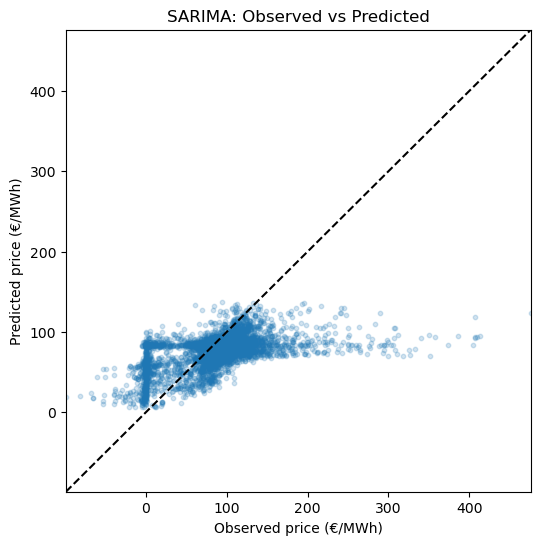

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_fc, alpha=0.2, s=10)
lims = [
    min(y_test.min(), test_fc.min()),
    max(y_test.max(), test_fc.max())
]
plt.plot(lims, lims, linestyle="--", color="black")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Observed price (€/MWh)")
plt.ylabel("Predicted price (€/MWh)")
plt.title("SARIMA: Observed vs Predicted")
plt.show()

**Plot summary:** the plot shows a systematic flattening of predictions at higher price levels, where points increasingly fall below the diagonal. As a result high price spikes are systematically underpredicted. This behavior leads to frequent moderate errors (reflected in a slightly higher MAE). At the same time extremely large deviations are avoided, which keeps the RMSE at a level comparable to the naive baseline.

## Level 2: Linear Regression 

Our linear regression model use a compact set of explanatory variables that represent the dominant structural drivers of day-ahead electricity prices.

* The main variable is **forecasted residual load**. Residual load reflects the amount of demand that must be covered by conventional generation. EDA showed a substantially stronger relationship of residual load with the prices than with demand alone. Solar and wind forecasts are not included separately, since their effect is already contained in residual load. Therefore, doing so could introduce strong multicollinearity.

* To capture short-term price persistence, the **day-ahead price lagged by 24 hours** is added. This variable represents systematic bidding behavior and daily market structure.

* Calendar effects are modeled using binary indicators for **weekends** and **public holidays**.

* Intraday seasonality is represented by **sine and cosine transformations of the hour of day**. Hours are encoded trigonometrically, since hour 23 and hour 0 are adjacent in reality, but numerically they are far apart, which distorts any linear relationship. Sine and cosine map the 24-hour clock onto a circle to preserve the cyclical nature of time.

  > **Weather forecast variables** are intentionally excluded from our linear regression model, because they exhibit very high correlations with solar and wind forecasts. The last ones are already included through residual load. So, adding weather data would primarily add redundant information and could degrade stability of the model. However, we will be still investigating whether they can help achieve better predictions in our non-linear model - XGBoost.

### Step 1: Extracting parameters and target

In [26]:
df_lr = df.copy()

# target
y = df_lr['Price_DayAhead']

df_lr['Residual_Load'] = df_lr['Load_Forecast'] - df_lr['Solar'] - df_lr['Wind_Onshore'] - df_lr['Wind_Offshore']
df_lr['Price_lag_24'] = df_lr['Price_DayAhead'].shift(24)

# intraday seasonality
hour = df_lr.index.tz_convert("Europe/Berlin").hour
df_lr["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df_lr["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

# day-type flags
df_lr["is_weekend"] = df_lr["is_weekend"].astype(int)
df_lr["is_holiday"] = df_lr["is_holiday"].astype(int)

# feature matrix
X = df_lr[["Residual_Load", "Price_lag_24", "is_weekend", "is_holiday", "hour_sin", "hour_cos"]]

# dropping rows with NaNs created by lagging (first 24 hours)
data = pd.concat([y, X], axis=1).dropna()
y = data["Price_DayAhead"]
X = data.drop(columns=["Price_DayAhead"])

### Step 2: Diving data into train and test sets

Since the linear regression model does not require hyperparameter tuning, a simple train–test split with 80/20 proportion should be sufficient. 

In [27]:
split_time = "2025-06-01" # starting point for testing
train_mask = X.index < split_time
test_mask  = ~train_mask
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 21142
Test samples: 5683


### Step 3: Standardizing data
Prior to model estimation, all explanatory variables are standardized using z-score normalization. This is necessary because the predictors operate on very different numerical ranges. For example, residual load typically varies between 10 000–60 000 MW, lagged prices between roughly 0–200 €/MWh, while time-based features (sin, cos) are bounded within [−1, 1]. Standardization prevents scale differences from dominating the estimation.

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

### Step 4: Predicting & Evaluating

In [29]:
import statsmodels.api as sm

lr_model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
y_pred = lr_model.predict(sm.add_constant(X_test_scaled))

print(f"SUMMARY: \n {lr_model.summary()}")
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = mean_squared_error(y_test, y_pred) ** 0.5
print("--------------------------------------")
print(f"MAE : {mae_lr:.3f} €/MWh")
print(f"RMSE: {rmse_lr:.3f} €/MWh")

SUMMARY: 
                             OLS Regression Results                            
Dep. Variable:         Price_DayAhead   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                 1.010e+04
Date:                Fri, 23 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:02:22   Log-Likelihood:                -99174.
No. Observations:               21142   AIC:                         1.984e+05
Df Residuals:                   21135   BIC:                         1.984e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            88.4920      0.181

### Interpretation of the summary
* High explanatory power ($R^2 \approx 0.75$): around 75% of the variance in day-ahead electricity prices is explained by the included predictors.
* Jointly statistically significant (F-statistic p-value = 0). This confirms that our model parameters provide meaningful information beyond a constant baseline.
* Residual load is the strongest predictor. It has a positive coefficient, confirming that higher residual load is associated with higher electricity prices.
### Error interpretation
Compared to the baseline persistence model (MAE $\approx$ 27 €/MWh, RMSE $\approx$ 41 €/MWh), the linear regression model substantially improves predictive performance, reducing the MAE to ~16.33 €/MWh and the RMSE to around 24 €/MWh. This indicates both better average accuracy and fewer large forecast errors. To understand model's performance even better, observed and predicted prices are depicted in the plot below.

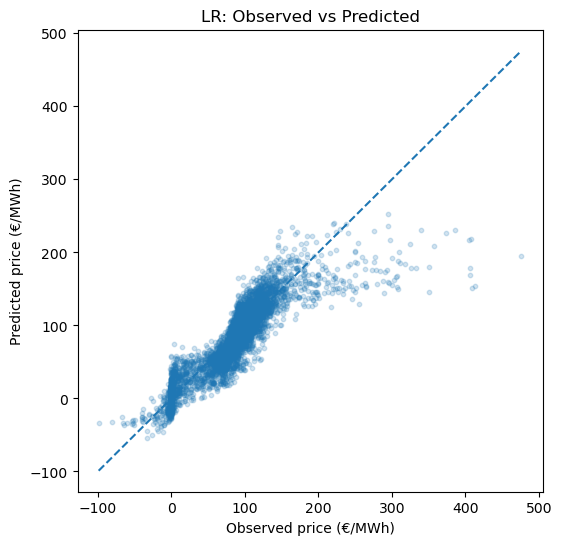

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.title("LR: Observed vs Predicted")
plt.xlabel("Observed price (€/MWh)")
plt.ylabel("Predicted price (€/MWh)")
plt.show()

**Plot summary:** The most of observations lies close to the diagonal line for low to moderate prices, indicating that the model predicts typical market conditions reasonably well. 
Compared to SARIMA and the naive baseline, linear regression achieves notably lower MAE and RMSE. However, the plot still shows that extreme price spikes remain underestimated. This highlights the limitations of a purely linear model.

## Level 3: XGBoost

XGBoost (eXtreme Gradient Boosting) is a tree-based ensemble method that builds models sequentially, where each new tree corrects the errors of the previous ones. Unlike linear regression, XGBoost can capture nonlinear relationships and feature interactions without explicit specification. 

The model uses the same core predictors as linear regression:

* Forecasted residual load as the primary driver of conventional generation dispatch
* Day-ahead price lagged by 24 hours to capture daily price persistence
* Weekend and holiday indicators for calendar effects
* Sine and cosine transformations of the hour for intraday seasonality

Additionally, we test whether adding weather forecast variables (temperature, wind speed, solar radiation) improves prediction accuracy. While these were excluded from linear regression due to high correlation with the ENTSO-E generation forecasts (which would cause multicollinearity), XGBoost as a tree-based method is robust to correlated features. We compare both variants to quantify the added value of weather data.

### Step 1: Extracting features and target


In [31]:
df_xgb = df_lr.copy()

# feature matrix (same features as LR + weather variables)
features = [
    "Residual_Load", "Price_lag_24", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", 
    "Weather_Temp_Forecast", "Weather_Wind_Forecast", "Weather_Solar_Forecast"
]
X = df_xgb[features]
y = df_xgb["Price_DayAhead"]

# dropping rows with NaNs created by lagging
data = pd.concat([y, X], axis=1).dropna()
y = data["Price_DayAhead"]
X = data.drop(columns=["Price_DayAhead"])

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

Feature matrix shape: (26825, 9)
Features: ['Residual_Load', 'Price_lag_24', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'Weather_Temp_Forecast', 'Weather_Wind_Forecast', 'Weather_Solar_Forecast']


### Step 2: Dividing data into train and test sets
The same temporal split as in linear regression is used to ensure comparability. All data before 2025-06-01 is used for training (including hyperparameter tuning), and all data onward is held out for final evaluation.


In [32]:
split_time = "2025-06-01"
train_mask = X.index < split_time
test_mask = ~train_mask

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 21142
Test samples: 5683


### Step 3: Hyperparameter tuning with time-series cross-validation

XGBoost has several hyperparameters that control model complexity. The most important ones are:

| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Number of boosting rounds (trees) |
| `max_depth` | Maximum depth of each tree |
| `learning_rate` | Step size shrinkage to prevent overfitting |
| `min_child_weight` | Minimum sum of instance weight needed in a child node |
| `subsample` | Fraction of training samples used per tree |

To find optimal values, we use TimeSeriesSplit cross-validation, which creates expanding training windows while always validating on future data. This respects the temporal structure of the data and prevents information leakage from future to past.


In [33]:
!pip install xgboost
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb

# define parameter grid
param_grid = {
    "n_estimators": [50, 100, 500, 1000],
    "max_depth": [2, 3],              
    "learning_rate": [0.01, 0.05],   
    "min_child_weight": [1, 5, 10, 15],    
    "subsample": [0.8, 1.0]          
}

# time-series cross-validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

# base model
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# grid search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.3f} €/MWh")

Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best parameters: {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 15, 'n_estimators': 1000, 'subsample': 1.0}
Best CV MAE: 18.243 €/MWh


### Step 4: Training final model and evaluation
The final model is trained on the full training set using the optimal hyperparameters found during cross-validation. Unlike linear regression, XGBoost does not require feature standardization.

In [34]:
best_model = grid_search.best_estimator_
y_pred_xgb = best_model.predict(X_test)

# evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"MAE:  {mae_xgb:.3f} €/MWh")
print(f"RMSE: {rmse_xgb:.3f} €/MWh")

MAE:  14.039 €/MWh
RMSE: 22.424 €/MWh


### Comparison: With vs. without weather variables

To evaluate whether the weather variables contribute meaningful information, we train a second XGBoost model using only the same features as linear regression (without weather). To ensure a fair comparison, we perform a separate hyperparameter search for the reduced feature set, as hyperparameters may differ between models with different numbers of features.


In [35]:
# Comparison: Model WITHOUT weather variables
features_no_weather = [
    "Residual_Load", "Price_lag_24", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos"
]

X_nw = df_xgb[features_no_weather]
y_nw = df_xgb["Price_DayAhead"]

# dropping rows with NaNs
data_nw = pd.concat([y_nw, X_nw], axis=1).dropna()
y_nw = data_nw["Price_DayAhead"]
X_nw = data_nw.drop(columns=["Price_DayAhead"])

# same train/test split
X_train_nw, y_train_nw = X_nw.loc[train_mask], y_nw.loc[train_mask]
X_test_nw, y_test_nw = X_nw.loc[test_mask], y_nw.loc[test_mask]

# separate grid search for model without weather
grid_search_nw = GridSearchCV(
    estimator=xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)
grid_search_nw.fit(X_train_nw, y_train_nw)

print(f"\nBest parameters (no weather): {grid_search_nw.best_params_}")
print(f"Best CV MAE (no weather): {-grid_search_nw.best_score_:.3f} €/MWh")

# train final model and predict
model_no_weather = grid_search_nw.best_estimator_
y_pred_nw = model_no_weather.predict(X_test_nw)

# comparison
mae_no_weather = mean_absolute_error(y_test_nw, y_pred_nw)
rmse_no_weather = np.sqrt(mean_squared_error(y_test_nw, y_pred_nw))

print("Model comparison:")
print(f"  WITH weather:    MAE = {mae_xgb:.3f} €/MWh,  RMSE = {rmse_xgb:.3f} €/MWh")
print(f"  WITHOUT weather: MAE = {mae_no_weather:.3f} €/MWh,  RMSE = {rmse_no_weather:.3f} €/MWh")
print(f"  Difference:      MAE = {mae_no_weather - mae_xgb:.3f} €/MWh")


Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best parameters (no weather): {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV MAE (no weather): 18.075 €/MWh
Model comparison:
  WITH weather:    MAE = 14.039 €/MWh,  RMSE = 22.424 €/MWh
  WITHOUT weather: MAE = 14.472 €/MWh,  RMSE = 23.914 €/MWh
  Difference:      MAE = 0.433 €/MWh


**Interpretation:** The comparison shows that adding weather variables provides only a marginal improvement in prediction accuracy. This suggests that the ENTSO-E generation forecasts already capture most of the weather-related price effects. The weather variables from Open-Meteo may contain some additional information about forecast uncertainty or regional variations, but their contribution is limited. For the remainder of this analysis, we proceed with the model including weather variables, as it achieves the best performance.

### Interpretation of model performance

The hyperparameter search evaluated 128 parameter combinations (4 × 2 × 2 × 4 × 2) across 5 time-series folds, resulting in 640 model fits. The optimal configuration uses:

* `max_depth = 2`: Very shallow trees, indicating that simple decision rules are sufficient
* `min_child_weight = 15`: Higher regularization to prevent overfitting on small subgroups
* `learning_rate = 0.05`: Moderate shrinkage for stable learning
* `n_estimators = 100`: Relatively few trees needed due to shallow depth
* `subsample = 1.0`: Full training data used per tree

The preference for shallow trees and strong regularization suggests that the underlying price-feature relationships are relatively smooth and do not require deep hierarchical splits. This aligns with the finding that residual load alone explains much of the price variation.

Compared to the baseline persistence model (MAE = 27.09 €/MWh) and linear regression (MAE = 16.327 €/MWh), the XGBoost model achieves further improvement with MAE = 14.095 €/MWh.


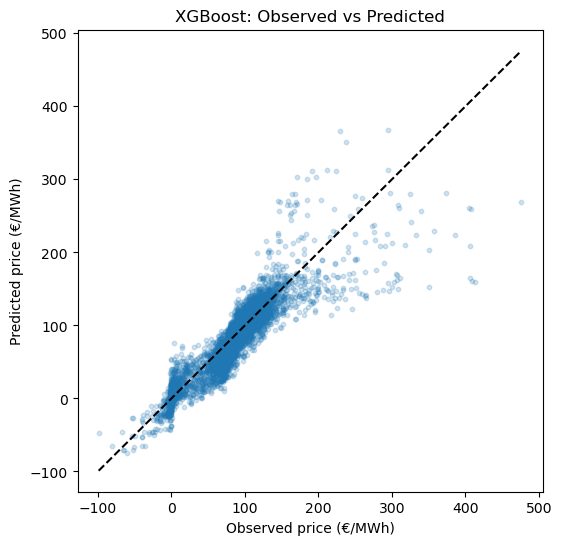

In [36]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.2, s=10)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--", color="black"
)
plt.xlabel("Observed price (€/MWh)")
plt.ylabel("Predicted price (€/MWh)")
plt.title("XGBoost: Observed vs Predicted")
plt.show()

**Plot summary:** XGBoost achieves tighter predictions around the diagonal, particularly in the low-to-mid price range (0–150 €/MWh). While linear regression shows systematic underprediction at higher prices, XGBoost reduces this bias somewhat, though both models still underpredict extreme price spikes.

### Feature importance analysis

XGBoost provides a built-in measure of feature importance based on how often each feature is used in tree splits and how much it contributes to reducing the prediction error.


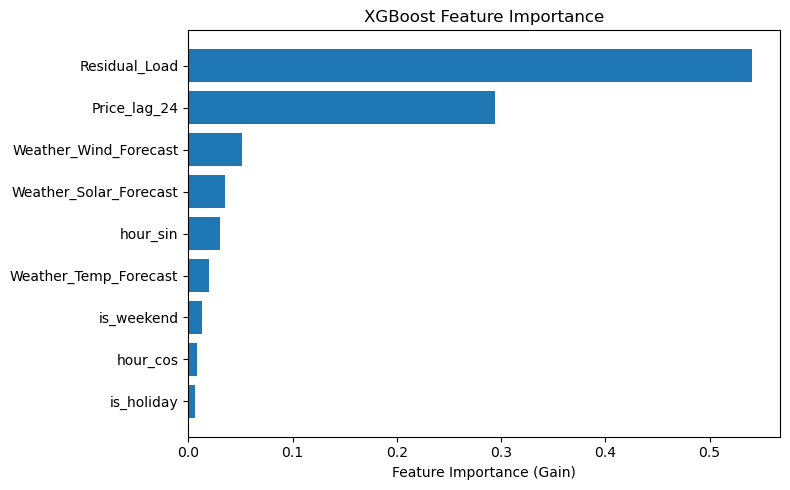

In [37]:
importance = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

**Interpretation of Feature Importance**:<br>Residual Load dominates the prediction, confirming its central role in price formation.<br>
The cyclical hour features (hour_sin, hour_cos) jointly capture intraday price patterns arising from demand cycles and solar generation. Weather variables make moderate contributions, potentially capturing information not fully reflected in the ENTSO-E generation forecasts.<br>
The binary time features is_weekend and is_holiday have low importance, likely because their influence on prices is already captured through residual load (lower demand on weekends and holidays reduces residual load, which in turn affects prices).

## Part 4. Conclusion
### 4.1 Results

The figure below compares MAE and RMSE across our four forecasting models on the test set.

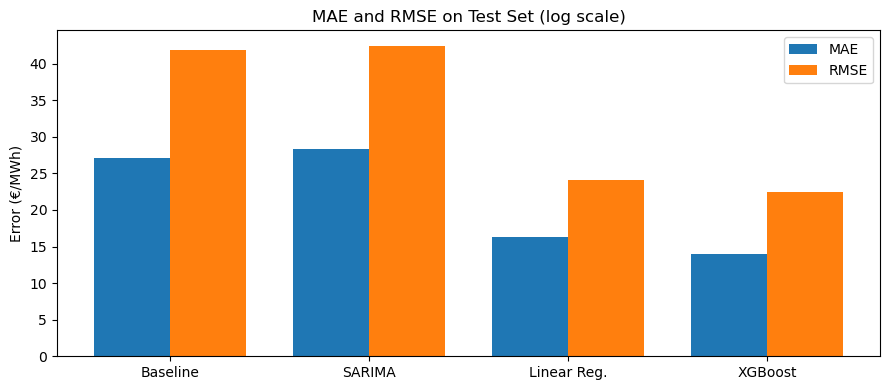

In [40]:
models = ["Baseline", "SARIMA", "Linear Reg.", "XGBoost"]
mae = [mae_base, mae_sar, mae_lr, mae_xgb]
rmse = [rmse_base, rmse_sar, rmse_lr, rmse_xgb]

x = np.arange(len(models))
w = 0.38

plt.figure(figsize=(9, 4))
plt.bar(x - w/2, mae, width=w, label="MAE")
plt.bar(x + w/2, rmse, width=w, label="RMSE")
plt.xticks(x, models)
plt.ylabel("Error (€/MWh)")
plt.title("MAE and RMSE on Test Set")
plt.legend()
plt.tight_layout()
plt.show()

**Plot summary:** The naive baseline and SARIMA models exhibit similarly high error levels. Thus, SARIMA does not provide a meaningful improvement over a persistence forecast. Linear regression substantially reduces both MAE and RMSE, indicating a clear gain in average predictive accuracy. XGBoost provides a small but consistent improvement over linear regression, which indicates the presence of weak nonlinear effects. However, the majority of the performance gain seems to arise from incorporating relevant explanatory variables rather than from model complexity alone.

### 4.2 Predictions for January 27th, 2026

### 4.3 Potential improvements
The models perform well for typical price levels, but all of them struggle during extreme price spikes. This indicates that some important drivers of electricity prices are missing.

We tried to include additional variables such as gas prices and CO₂ prices. However, we could not find reliable and up-to-date data with the required hourly resolution and forecast availability. Therefore, these variables were not included in the final models.

All models in this study produce point forecasts only. In future work, probabilistic forecasting could be considered to better reflect uncertainty, especially during volatile periods.

Neural network–based models could also be a good fit. They may better capture nonlinear relationships and complex interactions between load, weather, and prices. However, they usually require more data and careful tuning and their interpretability is lower compared to linear models.

Finally, further feature engineering, such as separating peak and off-peak hours or adding interaction terms, could improve model performance.

In [39]:
# ------ GENERATING PDF FILE ------
!jupyter nbconvert --to webpdf --embed-images --allow-chromium-download draft_project.ipynb

[NbConvertApp] Converting notebook draft_project.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1006253 bytes to draft_project.pdf
